<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Cryogenic_CMOS_and_Cryogenic_MRAM_Power_Dissipation_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

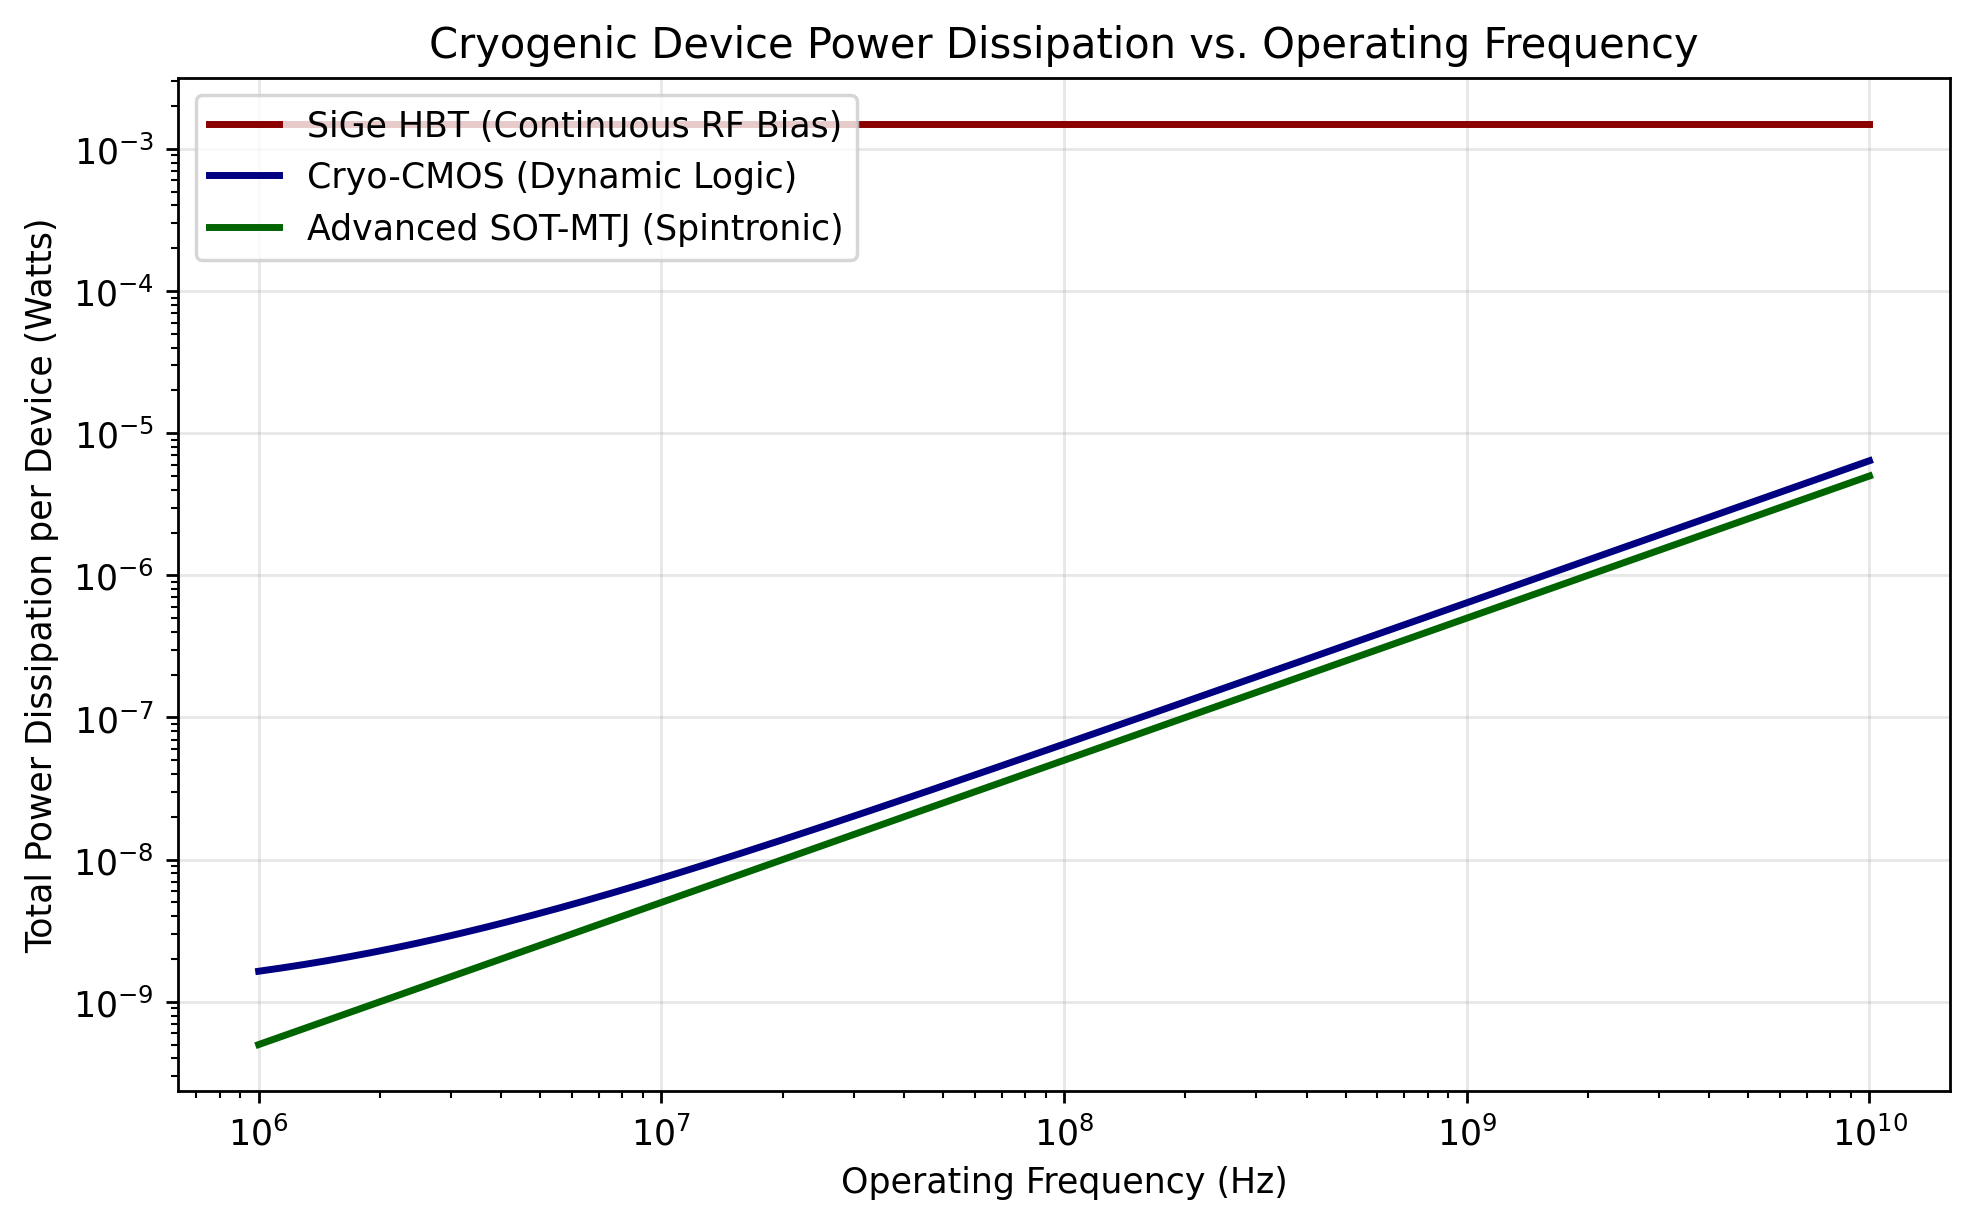

In [1]:
"""
Module to simulate and visualize Joule heating in cryogenic devices.

This script compares the power dissipation of SiGe HBTs, Cryo-CMOS,
and Advanced SOT-MTJs across a range of operating frequencies.
"""

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONTROL KNOBS (Parameter Adjustment)
# ==========================================

# Frequency range: 1 MHz to 10 GHz
FREQUENCY_HZ = np.logspace(6, 10, 500)

# SiGe HBT Parameters (Class A Amplifier)
SIGE_IC_AMPS = 1.0e-3      # Collector current: 1 mA
SIGE_VCE_VOLTS = 1.5       # Collector-emitter voltage: 1.5 V

# Cryo-CMOS Parameters (Inverter Logic)
CMOS_VDD_VOLTS = 0.8       # Drain supply voltage: 0.8 V
CMOS_CLOAD_FARADS = 10e-15 # Load capacitance: 10 fF
CMOS_ALPHA = 0.1           # Activity factor (10% switching probability)
CMOS_LEAKAGE_WATTS = 1e-9  # Static leakage power: 1 nW

# Advanced SOT-MTJ Parameters (Memory/Logic)
# Assuming energy per switch is constant and scaling with frequency of operations
MTJ_ENERGY_PER_SWITCH_JOULES = 50e-15  # Switching energy: 50 fJ
MTJ_ALPHA = 0.01                       # Activity factor (memory accessed less frequently)

# Plotting Configuration
plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ==========================================
# CALCULATIONS
# ==========================================

def calculate_sige_power() -> np.ndarray:
    """
    Calculate the total power dissipation for a SiGe HBT.
    Power is dominated by the continuous DC bias.

    Returns:
        np.ndarray: Power dissipation array in Watts.
    """
    static_power = SIGE_IC_AMPS * SIGE_VCE_VOLTS
    # Assuming frequency dependence is negligible for basic static thermal load
    return np.full_like(FREQUENCY_HZ, static_power)

def calculate_cmos_power(freq: np.ndarray) -> np.ndarray:
    """
    Calculate the total power dissipation for a Cryo-CMOS gate.
    Power is dominated by dynamic switching CV^2f.

    Args:
        freq (np.ndarray): Array of operating frequencies in Hz.

    Returns:
        np.ndarray: Power dissipation array in Watts.
    """
    dynamic_power = CMOS_ALPHA * CMOS_CLOAD_FARADS * (CMOS_VDD_VOLTS ** 2) * freq
    return CMOS_LEAKAGE_WATTS + dynamic_power

def calculate_mtj_power(freq: np.ndarray) -> np.ndarray:
    """
    Calculate the total power dissipation for an SOT-MTJ.
    Power is driven purely by transient switching energy.

    Args:
        freq (np.ndarray): Array of operating frequencies in Hz.

    Returns:
        np.ndarray: Power dissipation array in Watts.
    """
    return MTJ_ALPHA * MTJ_ENERGY_PER_SWITCH_JOULES * freq

# ==========================================
# EXECUTION AND RENDERING
# ==========================================

def main() -> None:
    """Execute calculations and render the comparison plot."""
    power_sige = calculate_sige_power()
    power_cmos = calculate_cmos_power(FREQUENCY_HZ)
    power_mtj = calculate_mtj_power(FREQUENCY_HZ)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.loglog(FREQUENCY_HZ, power_sige, label='SiGe HBT (Continuous RF Bias)',
              color='darkred', linewidth=2)
    ax.loglog(FREQUENCY_HZ, power_cmos, label='Cryo-CMOS (Dynamic Logic)',
              color='navy', linewidth=2)
    ax.loglog(FREQUENCY_HZ, power_mtj, label='Advanced SOT-MTJ (Spintronic)',
              color='darkgreen', linewidth=2)

    ax.set_title('Cryogenic Device Power Dissipation vs. Operating Frequency')
    ax.set_xlabel('Operating Frequency (Hz)')
    ax.set_ylabel('Total Power Dissipation per Device (Watts)')
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

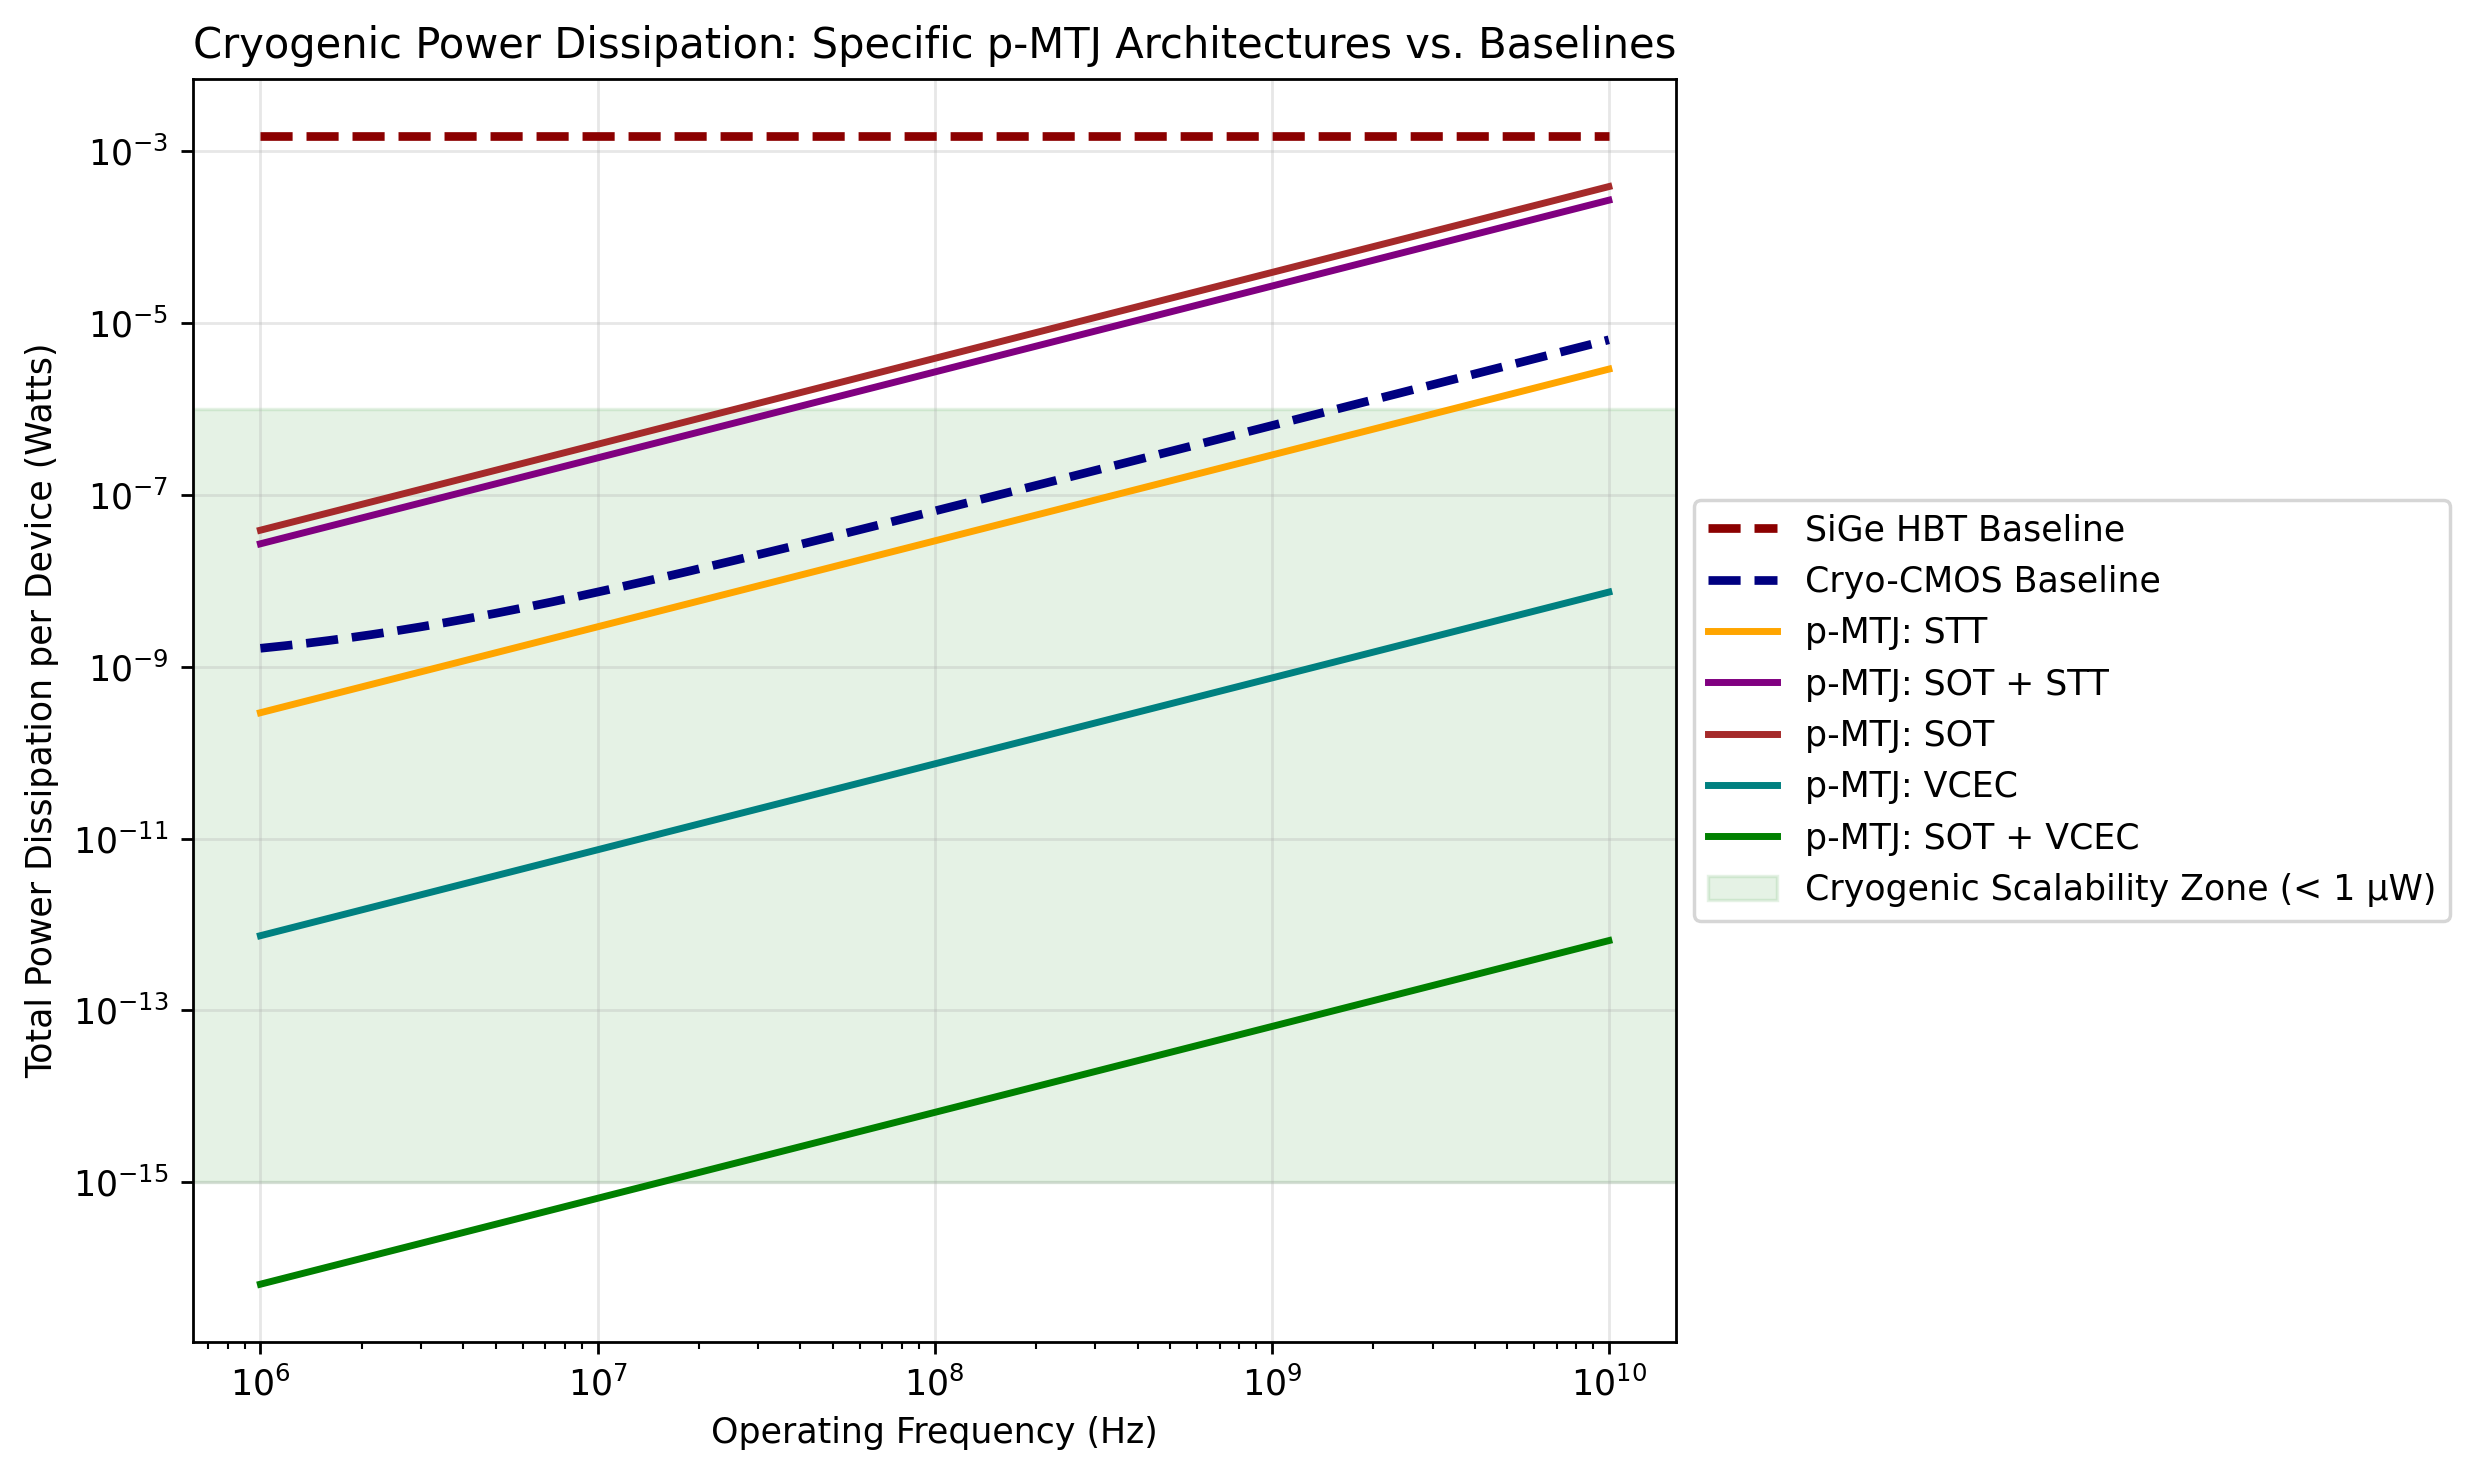

In [3]:
"""
Module to simulate and visualize Joule heating in specific p-MTJ architectures.

This script compares the power dissipation of specific STT, SOT, and VCEC MTJ
devices derived from empirical literature against SiGe HBTs and Cryo-CMOS
across a range of operating frequencies.
"""

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONTROL KNOBS (Parameter Adjustment)
# ==========================================

# Frequency range: 1 MHz to 10 GHz
FREQUENCY_HZ = np.logspace(6, 10, 500)

# Activity Factors
ALPHA_LOGIC = 0.1  # 10% switching probability for CMOS logic
ALPHA_MTJ = 0.01   # 1% switching probability for embedded memory

# Device Resistances (Assumed physical constants for I^2R calculation)
R_BARRIER_OHMS = 1000.0  # Resistance for current passing through MgO barrier
R_TRACK_OHMS = 100.0     # Resistance for current passing through heavy-metal SOT track

# 1. SiGe HBT Parameters (Class A RF Amplifier)
SIGE_IC_AMPS = 1.0e-3    # 1 mA
SIGE_VCE_VOLTS = 1.5     # 1.5 V

# 2. Cryo-CMOS Parameters (Inverter Logic)
CMOS_VDD_VOLTS = 0.8       # 0.8 V
CMOS_CLOAD_FARADS = 10e-15 # 10 fF
CMOS_LEAKAGE_WATTS = 1e-9  # 1 nW

# 3. p-MTJ Parameters (Derived Absolute Current [A] & Duration [s])
# Format: (Current in Amps, Duration in Seconds, Resistance in Ohms)
MTJ_SPECS = {
    'STT':        (180e-6,  0.90e-9, R_BARRIER_OHMS),
    'SOT + STT':  (10e-3,   0.27e-9, R_TRACK_OHMS),
    'SOT':        (12e-3,   0.27e-9, R_TRACK_OHMS),
    'VCEC':       (8.6e-6,  1.00e-9, R_BARRIER_OHMS), # Duration assumed 1.0 ns
    'SOT + VCEC': (0.49e-6, 0.27e-9, R_TRACK_OHMS)
}

# Plotting Configuration
plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ==========================================
# CALCULATIONS
# ==========================================

def calculate_sige_power() -> np.ndarray:
    """Calculate the static continuous DC power dissipation for a SiGe HBT."""
    return np.full_like(FREQUENCY_HZ, SIGE_IC_AMPS * SIGE_VCE_VOLTS)

def calculate_cmos_power(freq: np.ndarray) -> np.ndarray:
    """Calculate the dynamic CV^2f + static leakage power for Cryo-CMOS."""
    dynamic_power = ALPHA_LOGIC * CMOS_CLOAD_FARADS * (CMOS_VDD_VOLTS ** 2) * freq
    return CMOS_LEAKAGE_WATTS + dynamic_power

def calculate_mtj_power(freq: np.ndarray, i_sw: float, tau: float, res: float) -> np.ndarray:
    """
    Calculate the dynamic transient switching power for a specific MTJ architecture.
    Energy per switch = I^2 * R * tau.
    """
    energy_per_switch = (i_sw ** 2) * res * tau
    return ALPHA_MTJ * energy_per_switch * freq

# ==========================================
# EXECUTION AND RENDERING
# ==========================================

def main() -> None:
    """Execute energy calculations and render the architectural comparison."""
    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. Plot Baseline Devices
    power_sige = calculate_sige_power()
    ax.loglog(FREQUENCY_HZ, power_sige, label='SiGe HBT Baseline',
              color='darkred', linewidth=2.5, linestyle='--')

    power_cmos = calculate_cmos_power(FREQUENCY_HZ)
    ax.loglog(FREQUENCY_HZ, power_cmos, label='Cryo-CMOS Baseline',
              color='navy', linewidth=2.5, linestyle='--')

    # 2. Plot Specific p-MTJ Architectures
    colors = ['orange', 'purple', 'brown', 'teal', 'green']

    for (name, (i_sw, tau, res)), color in zip(MTJ_SPECS.items(), colors):
        power_mtj = calculate_mtj_power(FREQUENCY_HZ, i_sw, tau, res)
        ax.loglog(FREQUENCY_HZ, power_mtj, label=f'p-MTJ: {name}',
                  color=color, linewidth=2)

    # 3. Formatting
    ax.set_title('Cryogenic Power Dissipation: Specific p-MTJ Architectures vs. Baselines')
    ax.set_xlabel('Operating Frequency (Hz)')
    ax.set_ylabel('Total Power Dissipation per Device (Watts)')

    # Add a horizontal span to denote the typical cooling limit of a dilution fridge
    # at the 4 Kelvin stage (~1 Watt total budget, meaning micro-watts per device for dense arrays)
    ax.axhspan(1e-15, 1e-6, color='green', alpha=0.1, label='Cryogenic Scalability Zone (< 1 µW)')

    # Place legend outside the main plot area to prevent occlusion
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()